<a href="https://colab.research.google.com/github/ilyilayda/cv_pneumonia_detection/blob/main/comp_vision_term_project_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", device)

Kullanılan cihaz: cuda


In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "laydadinklah"
os.environ['KAGGLE_KEY'] = "KGAT_dd29b83a08fa26d2c3d5afb800090378"

In [ ]:
!pip install -q kaggle

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 133MB/s]



In [ ]:
!unzip chest-xray-pneumonia.zip

Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating: che

In [ ]:
import os
import shutil
import random

def create_small_dataset(src, dst, sample_size=200):
    os.makedirs(dst, exist_ok=True)

    for class_name in os.listdir(src):
        class_path = os.path.join(src, class_name)
        if not os.path.isdir(class_path):
            continue

        files = os.listdir(class_path)
        sampled = random.sample(files, min(sample_size, len(files)))

        os.makedirs(os.path.join(dst, class_name), exist_ok=True)

        for f in sampled:
            shutil.copy(os.path.join(class_path, f),
                        os.path.join(dst, class_name, f))

create_small_dataset("/content/chest_xray/train", "/content/small_train", 200)

In [ ]:
base_dir = "/content/chest_xray/chest_xray"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

print("Train klasörü:", os.listdir(train_dir))
print("Validation klasörü:", os.listdir(val_dir))
print("Test klasörü:", os.listdir(test_dir))

Train klasörü: ['PNEUMONIA', '.DS_Store', 'NORMAL']
Validation klasörü: ['PNEUMONIA', '.DS_Store', 'NORMAL']
Test klasörü: ['PNEUMONIA', '.DS_Store', 'NORMAL']


In [ ]:
#Görselleri modele uygun hale getirme
'''train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])'''

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
#Dataset ve DataLoader’ı oluştur
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=test_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train örnek sayısı:", len(train_dataset))
print("Validation örnek sayısı:", len(val_dataset))
print("Test örnek sayısı:", len(test_dataset))
print("Sınıflar:", train_dataset.classes)

Train örnek sayısı: 5216
Validation örnek sayısı: 16
Test örnek sayısı: 624
Sınıflar: ['NORMAL', 'PNEUMONIA']


In [ ]:
#Class counts ve class weights hesapla
from collections import Counter

train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)

print("Class counts:", class_counts)
print("Class names:", train_dataset.classes)

num_samples = sum(class_counts.values())
num_classes = len(class_counts)

class_weights = []
for i in range(num_classes):
    weight = num_samples / (num_classes * class_counts[i])
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class counts: Counter({1: 3875, 0: 1341})
Class names: ['NORMAL', 'PNEUMONIA']
Class weights: tensor([1.9448, 0.6730], device='cuda:0')


In [ ]:
#Birkaç örnek görüntü göster
def show_samples(dataset, num_images=6):
    plt.figure(figsize=(15, 8))

    for i in range(num_images):
        image, label = dataset[i]

        # Tensor -> numpy
        image = image.numpy()

        # (C, H, W) -> (H, W, C)
        image = np.transpose(image, (1, 2, 0))

        # Normalize geri alma
        image = (image * 0.5) + 0.5

        # 0-1 aralığında tut
        image = np.clip(image, 0, 1)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title(dataset.classes[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

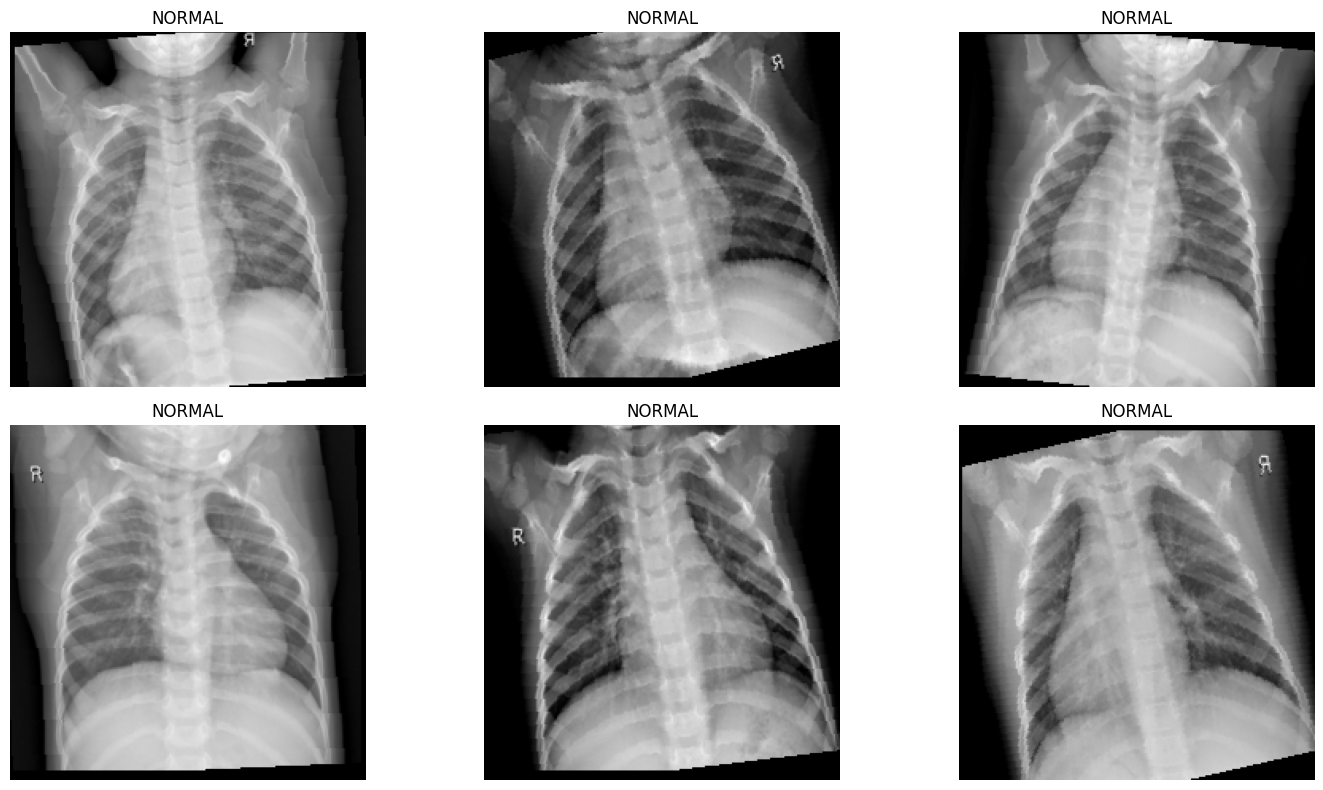

In [ ]:
show_samples(train_dataset, num_images=6)

# İlk basit CNN modeli

In [ ]:
#Güncellenmiş model
class SimpleCNNImproved(nn.Module):
    def __init__(self):
        super(SimpleCNNImproved, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Kodda Conv2d(3, 16, ...) yazdım. Bu şu demek:

Model 3 kanallı görüntü bekliyor.

Ama chest x-ray görüntüleri genelde grayscale. Buna rağmen ImageFolder + PIL bazı durumlarda görüntüyü RGB gibi açabiliyor. O yüzden önce gerçekten tensor şekline bakalım.

In [ ]:
sample_image, sample_label = train_dataset[0]
print("Görüntü boyutu:", sample_image.shape)

Görüntü boyutu: torch.Size([3, 224, 224])


In [ ]:
#Modeli oluştur
#model = SimpleCNN().to(device)
#print(model)

In [ ]:
#Model, weighted loss ve optimizer
model = SimpleCNNImproved().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print(model)

SimpleCNNImproved(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


CrossEntropyLoss()

İki sınıflı sınıflandırma için uygundur.

Adam

Başlangıç için kullanımı kolay ve güçlü bir optimizer’dır.

lr=1e-4

Learning rate’tir. Proposal’daki önerilen değerlerden biridir.

In [ ]:
#Tek batch deneyelim. Burada modelin bir batch’i işleyip işleyemediğini test ediyoruz.
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Output shape: torch.Size([16, 2])
Labels shape: torch.Size([16])


Şu anda neyi tamamlamış olduk?

* dataseti yükledik
* train/val/test klasörlerini hazırladık
* transforms yazdık
* dataloader oluşturduk
* örnek görüntüleri gösterdik
* baseline CNN modelini kurduk
* loss ve optimizer seçtik
* modelin veri üstünde çalıştığını test ettik

Bu, projenin temel iskeletidir.

In [ ]:
#Accuracy hesaplama fonksiyonu
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1) #en yüksek skorlu sınıfı seçer.
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    acc = correct / total
    return acc

In [ ]:
#Training fonksiyonu
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train() #Modeli eğitim moduna geçirir. Dropout gibi katmanlar buna göre davranır.

    running_loss = 0.0
    running_acc = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() #Bir önceki batch’in gradientlerini temizler.

        outputs = model(images) #Görüntüleri modele verir, tahmin üretir.
        loss = criterion(outputs, labels) #Tahminle gerçek etiket arasındaki hatayı hesaplar.

        loss.backward() #Gradient hesaplar.
        optimizer.step() #Model ağırlıklarını günceller.

        acc = calculate_accuracy(outputs, labels)

        running_loss += loss.item()
        running_acc += acc

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

In [ ]:
#Validation fonksiyonu
def validate_one_epoch(model, loader, criterion, device):
    model.eval() #Model validation moduna geçer.

    running_loss = 0.0
    running_acc = 0.0

    with torch.no_grad(): #Bu aşamada gradient hesaplanmaz çünkü öğrenme yok. Bu hem daha hızlıdır hem de daha az bellek kullanır.
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            acc = calculate_accuracy(outputs, labels)

            running_loss += loss.item()
            running_acc += acc

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

In [ ]:
#Yeni modeli eğit ve en iyisini kaydet
best_val_acc = 0.0
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_simple_cnn_weighted.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

print("En iyi validation accuracy:", best_val_acc)

Epoch [1/10]
Train Loss: 0.4266 | Train Acc: 0.8033
Val Loss:   0.6270 | Val Acc:   0.8125
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.2511 | Train Acc: 0.9045
Val Loss:   0.4284 | Val Acc:   0.8125
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.1948 | Train Acc: 0.9271
Val Loss:   0.5107 | Val Acc:   0.6875
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.1698 | Train Acc: 0.9362
Val Loss:   1.0736 | Val Acc:   0.6250
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.1593 | Train Acc: 0.9371
Val Loss:   0.6099 | Val Acc:   0.6875
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.1538 | Train Acc: 0.9427
Val Loss:   0.6428 | Val Acc:   0.6250
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.1493 | Train Acc: 0.9444
Val Loss:   0.9053 | Val Acc:   0.6250
--------------------------------------------------
Epoch 

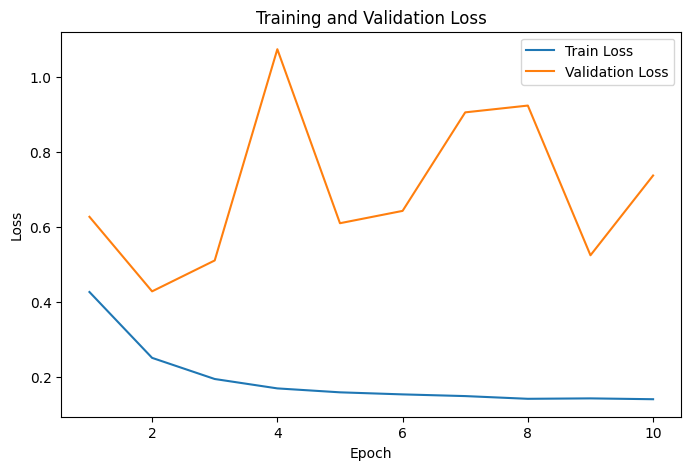

In [ ]:
#Loss grafiği çizme
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

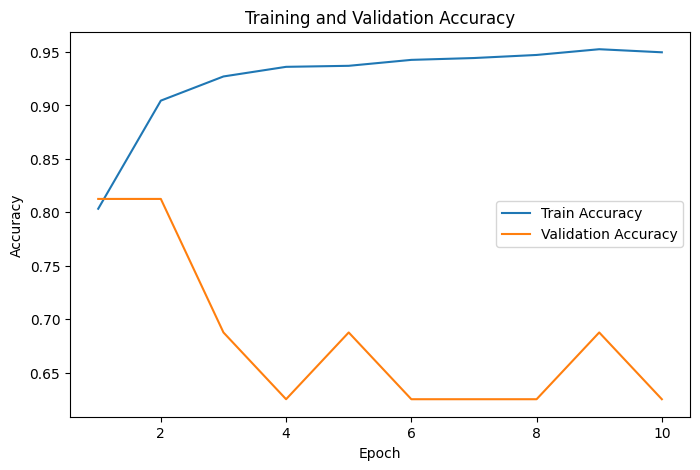

In [ ]:
#Accuracy grafiği çizme
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import seaborn as sns

In [ ]:
#Test değerlendirmesi için güncellenmiş model yükleme
best_model = SimpleCNNImproved().to(device)
best_model.load_state_dict(torch.load("best_simple_cnn_weighted.pth", map_location=device))
best_model.eval()

print("Improved model başarıyla yüklendi.")

Improved model başarıyla yüklendi.


In [ ]:
#Test set üzerinde tahmin toplama
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy()) #gerçek etiketler
        all_preds.extend(preds.cpu().numpy()) #modelin tahmin ettiği sınıflar
        all_probs.extend(probs[:, 1].cpu().numpy())  # pneumonia sınıfı olasılığı

In [ ]:
#Ana metrikleri hesapla
test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds)
test_recall = recall_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)
test_auc = roc_auc_score(all_labels, all_probs)

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-score:  {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_auc:.4f}")

Test Accuracy:  0.8462
Test Precision: 0.8534
Test Recall:    0.9103
Test F1-score:  0.8809
Test ROC-AUC:   0.9146


In [ ]:
#Classification report al
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

              precision    recall  f1-score   support

      NORMAL       0.83      0.74      0.78       234
   PNEUMONIA       0.85      0.91      0.88       390

    accuracy                           0.85       624
   macro avg       0.84      0.82      0.83       624
weighted avg       0.85      0.85      0.84       624



In [ ]:
#Confusion matrix çıkar
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[173  61]
 [ 35 355]]


Confusion matrix şöyle okunur:

* sol üst: normal doğru tahmin
* sağ üst: normal olup yanlış pneumonia denilen
* sol alt: pneumonia olup yanlış normal denilen
* sağ alt: pneumonia doğru tahmin



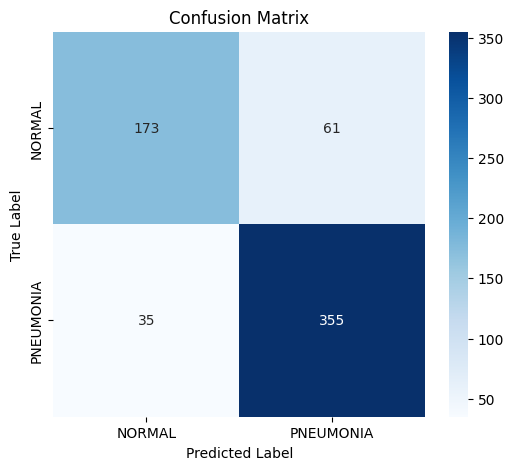

In [ ]:
#Confusion matrix görselleştir
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

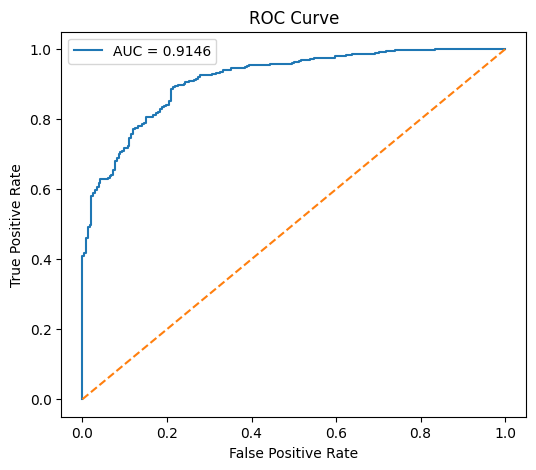

In [ ]:
#ROC curve çiz
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
results = {
    "Accuracy": test_acc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1,
    "ROC-AUC": test_auc
}

print(results)

{'Accuracy': 0.8461538461538461, 'Precision': 0.8533653846153846, 'Recall': 0.9102564102564102, 'F1-score': 0.8808933002481389, 'ROC-AUC': np.float64(0.9145737453429762)}


# ResNet-18 Transfer Learning Baseline

In [ ]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights

In [ ]:
#ResNet-18 modelini oluştur
resnet18 = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Son fully connected katmanı değiştiriyoruz
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 2)

resnet18 = resnet18.to(device)

print(resnet18)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 50.9MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Burada pretrained ResNet-18 kullanıyoruz. Modelin son katmanı normalde ImageNet için 1000 sınıf üretir. Biz bunu 2 sınıfa indiriyoruz: NORMAL ve PNEUMONIA.

In [ ]:
#Loss ve optimizer tanımla
criterion_resnet = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet = optim.Adam(resnet18.parameters(), lr=1e-4)

In [ ]:
#ResNet-18 için training başlat
best_val_acc_resnet = 0.0
num_epochs = 10

resnet_train_losses = []
resnet_train_accuracies = []
resnet_val_losses = []
resnet_val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        resnet18, train_loader, criterion_resnet, optimizer_resnet, device
    )

    val_loss, val_acc = validate_one_epoch(
        resnet18, val_loader, criterion_resnet, device
    )

    resnet_train_losses.append(train_loss)
    resnet_train_accuracies.append(train_acc)
    resnet_val_losses.append(val_loss)
    resnet_val_accuracies.append(val_acc)

    if val_acc > best_val_acc_resnet:
        best_val_acc_resnet = val_acc
        torch.save(resnet18.state_dict(), "best_resnet18.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

print("En iyi ResNet-18 validation accuracy:", best_val_acc_resnet)

Epoch [1/10]
Train Loss: 0.1624 | Train Acc: 0.9371
Val Loss:   0.9935 | Val Acc:   0.6875
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.0837 | Train Acc: 0.9688
Val Loss:   0.0488 | Val Acc:   1.0000
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.0749 | Train Acc: 0.9747
Val Loss:   0.0690 | Val Acc:   0.9375
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.0553 | Train Acc: 0.9801
Val Loss:   0.0300 | Val Acc:   1.0000
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.0524 | Train Acc: 0.9804
Val Loss:   0.3184 | Val Acc:   0.8750
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.0496 | Train Acc: 0.9799
Val Loss:   0.3730 | Val Acc:   0.8750
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.0468 | Train Acc: 0.9826
Val Loss:   0.0243 | Val Acc:   1.0000
--------------------------------------------------
Epoch 

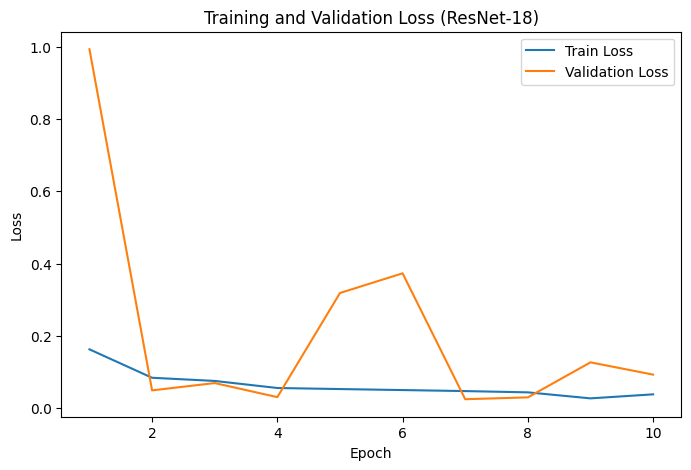

In [ ]:
#ResNet-18 loss grafiği
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), resnet_train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), resnet_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (ResNet-18)")
plt.legend()
plt.show()

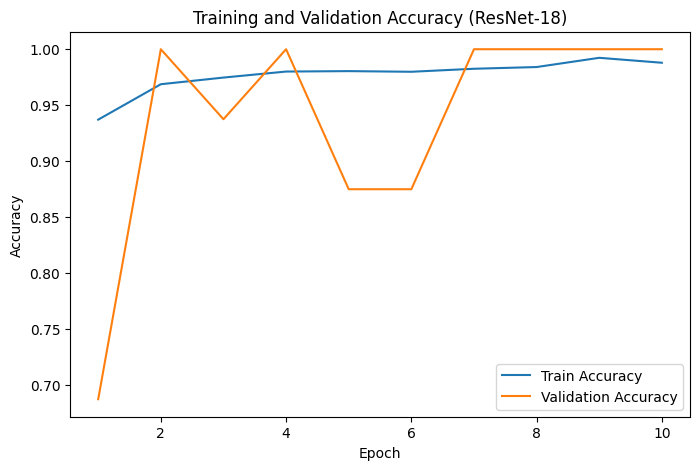

In [ ]:
#ResNet-18 accuracy grafiği
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), resnet_train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), resnet_val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy (ResNet-18)")
plt.legend()
plt.show()

In [ ]:
#En iyi ResNet-18 modelini yükle
best_resnet18 = models.resnet18(weights=None)

num_features = best_resnet18.fc.in_features
best_resnet18.fc = nn.Linear(num_features, 2)

best_resnet18.load_state_dict(torch.load("best_resnet18.pth", map_location=device))
best_resnet18 = best_resnet18.to(device)
best_resnet18.eval()

print("Best ResNet-18 modeli başarıyla yüklendi.")

Best ResNet-18 modeli başarıyla yüklendi.


In [ ]:
#ResNet-18 test değerlendirmesi
resnet_all_labels = []
resnet_all_preds = []
resnet_all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_resnet18(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        resnet_all_labels.extend(labels.cpu().numpy())
        resnet_all_preds.extend(preds.cpu().numpy())
        resnet_all_probs.extend(probs[:, 1].cpu().numpy())

In [ ]:
#ResNet-18 metrikleri
resnet_acc = accuracy_score(resnet_all_labels, resnet_all_preds)
resnet_precision = precision_score(resnet_all_labels, resnet_all_preds)
resnet_recall = recall_score(resnet_all_labels, resnet_all_preds)
resnet_f1 = f1_score(resnet_all_labels, resnet_all_preds)
resnet_auc = roc_auc_score(resnet_all_labels, resnet_all_probs)

print(f"ResNet-18 Test Accuracy:  {resnet_acc:.4f}")
print(f"ResNet-18 Test Precision: {resnet_precision:.4f}")
print(f"ResNet-18 Test Recall:    {resnet_recall:.4f}")
print(f"ResNet-18 Test F1-score:  {resnet_f1:.4f}")
print(f"ResNet-18 Test ROC-AUC:   {resnet_auc:.4f}")

ResNet-18 Test Accuracy:  0.8974
ResNet-18 Test Precision: 0.8826
ResNet-18 Test Recall:    0.9641
ResNet-18 Test F1-score:  0.9216
ResNet-18 Test ROC-AUC:   0.9661


In [ ]:
#Classification report
print(classification_report(
    resnet_all_labels,
    resnet_all_preds,
    target_names=test_dataset.classes
))

              precision    recall  f1-score   support

      NORMAL       0.93      0.79      0.85       234
   PNEUMONIA       0.88      0.96      0.92       390

    accuracy                           0.90       624
   macro avg       0.91      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624



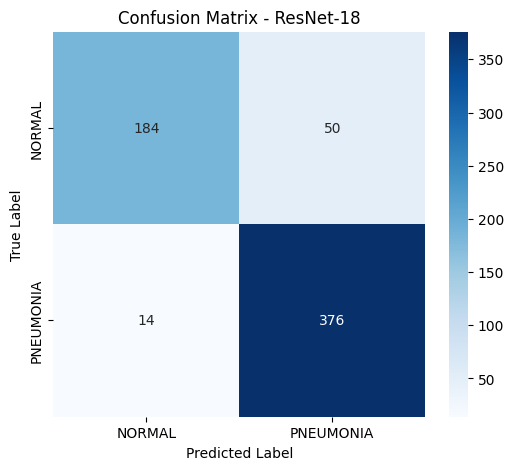

In [ ]:
#Confusion matrix
resnet_cm = confusion_matrix(resnet_all_labels, resnet_all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet-18")
plt.show()

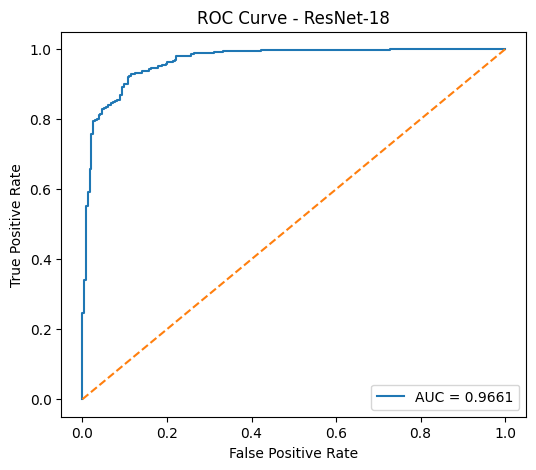

In [ ]:
#ROC Curve
resnet_fpr, resnet_tpr, resnet_thresholds = roc_curve(
    resnet_all_labels,
    resnet_all_probs
)

plt.figure(figsize=(6, 5))
plt.plot(resnet_fpr, resnet_tpr, label=f"AUC = {resnet_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ResNet-18")
plt.legend()
plt.show()

In [ ]:
#Model karşılaştırma tablosu
import pandas as pd
comparison_results = {
    "Model": ["Initial CNN", "Improved CNN", "ResNet-18"],
    "Accuracy": [0.7965, 0.8734, resnet_acc],
    "Precision": [0.7635, 0.8676, resnet_precision],
    "Recall": [0.9769, 0.9410, resnet_recall],
    "F1-score": [0.8571, 0.9028, resnet_f1],
    "ROC-AUC": [0.9295, 0.9367, resnet_auc]
}

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Initial CNN,0.796500,0.763500,0.976900,0.857100,0.929500
1,Improved CNN,0.873400,0.867600,0.941000,0.902800,0.936700
2,ResNet-18,0.897436,0.882629,0.964103,0.921569,0.966053


ResNet-18 significantly improves both classification performance and generalization compared to the custom CNN architecture.

ResNet-18 modeli, değerlendirilen tüm modeller arasında en iyi performansı göstermiştir. %89.7 doğruluk, 0.92 F1-score ve 0.966 ROC-AUC değeri elde edilmiştir. İlk ve iyileştirilmiş CNN modellerine kıyasla daha dengeli tahminler üretmiş ve genelleme performansı artmıştır. Confusion matrix analizinde hem false positive hem de false negative sayılarının azaldığı görülmektedir. Bu sonuçlar, transfer learning yaklaşımının medikal görüntü analizinde avantaj sağladığını göstermektedir.

# GRAD-CAM (Explanation Agent)

**Grad-CAM mantığı**

Modelin son convolution katmanına bakar ve şunu hesaplar:

“Bu tahmin için en önemli bölgeler neresi?”

***Sonuç: kırmızı = önemli, mavi = önemsiz***

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 61.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=6757509d4025f351f480012b5f4e311124fac3efdb30f2c2f1595737f2ed2076
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
#Model
model = SimpleCNNImproved().to(device)
model.load_state_dict(torch.load("best_simple_cnn_weighted.pth", map_location=device))
model.eval()

SimpleCNNImproved(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [ ]:
#Target layer seçimi
#Grad-CAM son convolution katmanını kullanır.

target_layer = model.features[6] #features[6] = son Conv2d katmanı

In [ ]:
#Test görüntüsü al
import random

img_path, label = random.choice(test_dataset.samples)
print("Gerçek sınıf:", test_dataset.classes[label])

image = Image.open(img_path).convert("RGB")

Gerçek sınıf: PNEUMONIA


In [ ]:
#Görüntüyü modele hazırla
input_tensor = test_transform(image).unsqueeze(0).to(device)

In [ ]:
#Model tahmini
output = model(input_tensor)
_, pred = torch.max(output, 1)

pred_class = pred.item()
print("Model tahmini:", test_dataset.classes[pred_class])

Model tahmini: PNEUMONIA


In [ ]:
#Grad-CAM oluştur
cam = GradCAM(model=model, target_layers=[target_layer])

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]

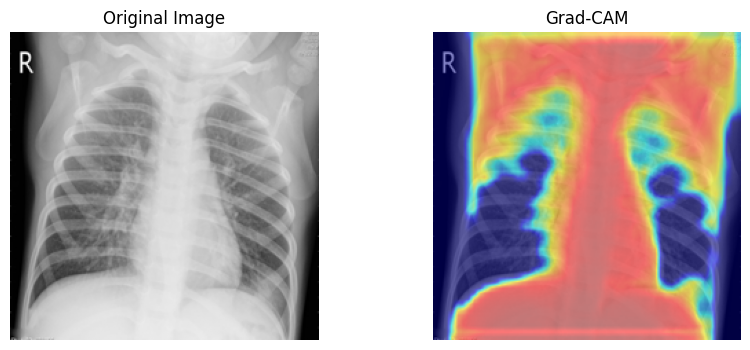

In [ ]:
#Görselleştir
import numpy as np

# Görüntüyü numpy formatına çevir
image_np = np.array(image.resize((224, 224))) / 255.0

cam_image = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cam_image)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

model üst üste birkaç kez çalıştırıldı ve alınan sonuçlar şu şekilde oldu:

1. örnek — NORMAL / NORMAL doğru tahmin:
Model doğru tahmin yapmış ama Grad-CAM yoğunluğu akciğerlerden çok üst köşelerde ve kenarlarda görünüyor. Bu, modelin normal kararını verirken tamamen medikal bölgelere odaklanmadığını gösterebilir.

2. örnek — PNEUMONIA / NORMAL yanlış tahmin:
Bu en önemli failure case. Model pneumonia görüntüsünü normal tahmin etmiş. Grad-CAM’de bazı akciğer bölgeleri vurgulanmış olsa da güçlü dikkat yine kenarlarda ve görüntü sınırlarında toplanmış. Bu, modelin hastalık bulgularını yeterince doğru yakalayamadığını gösteriyor.

3. örnek — PNEUMONIA / PNEUMONIA doğru tahmin:
Model doğru tahmin yapmış. Grad-CAM daha geniş bir bölgeyi vurguluyor; ancak sadece akciğer dokusuna değil, göğüs merkezi ve alt bölgelere de yayılmış. Bu nedenle tahmin doğru olsa bile açıklamanın tamamen güvenilir olduğunu söylemek zor.

Genel çıkarım

Grad-CAM sonuçları modelin bazı örneklerde doğru tahmin yaptığını, ancak dikkat haritalarının her zaman akciğer bölgelerine temiz şekilde odaklanmadığını gösteriyor. Bu durum proposal’daki Critic Agent fikrini destekliyor: model sadece tahmin üretmemeli, açıklamanın tıbbi olarak anlamlı bölgelere denk gelip gelmediği de kontrol edilmeli.

Grad-CAM analysis was applied to both correctly and incorrectly classified chest X-ray images. The results show that the model can correctly classify several pneumonia and normal cases; however, the highlighted regions are not always limited to medically relevant lung areas. In some cases, the model focuses on image borders, upper corners, or non-lung regions. This indicates that correct classification does not always guarantee reliable reasoning. Therefore, these qualitative Grad-CAM results support the need for a Critic Agent to quantitatively validate whether the explanation overlaps with lung regions.

# SHAP Explanation Agent

In [ ]:
!pip install shap

In [ ]:
import shap
import numpy as np
import torch
import matplotlib.pyplot as plt

In [ ]:
#SHAP için en iyi ResNet-18 modelini kullan
best_resnet18.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Background data seç
background_images, background_labels = next(iter(train_loader))

background_images = background_images[:5].to(device)

print("Background shape:", background_images.shape)

Background shape: torch.Size([5, 3, 224, 224])


SHAP için birkaç tane referans görüntü gerekiyor. Çok fazla seçerse yavaş çalışır. O yüzden küçük tutuyoruz.

In [ ]:
#Açıklanacak test görüntülerini seç
test_images, test_labels = next(iter(test_loader))

test_images = test_images[:2].to(device)
test_labels = test_labels[:2]

print("Test images shape:", test_images.shape)
print("True labels:", test_labels)


'''normal_samples = []
pneumonia_samples = []

for img, label in test_dataset:
    if label == 0 and len(normal_samples) < 1:
        normal_samples.append((img, label))
    elif label == 1 and len(pneumonia_samples) < 1:
        pneumonia_samples.append((img, label))

    if len(normal_samples) == 1 and len(pneumonia_samples) == 1:
        break

selected = normal_samples + pneumonia_samples

test_images = torch.stack([x[0] for x in selected]).to(device)
test_labels = torch.tensor([x[1] for x in selected])

print("Selected labels:", test_labels)

Test images shape: torch.Size([2, 3, 224, 224])
True labels: tensor([0, 0])


Shape kısmı --> [2, 3, 224, 224]

Bu şu demek:

* 2 → 2 tane görüntü seçtin
* 3 → RGB (3 kanal)
* 224x224 → boyut

Labels kısmı --> tensor([0, 0])

Bu şu demek:

* 0 = NORMAL
* 1 = PNEUMONIA

👉 Yani seçtiğin 2 görüntü de:

In [ ]:
#SHAP GradientExplainer oluştur
explainer = shap.GradientExplainer(best_resnet18, background_images)

In [ ]:
#SHAP değerlerini hesapla
shap_values = explainer.shap_values(test_images)

In [ ]:
#Görselleri SHAP için uygun formata getir
def denormalize_images(images):
    images = images.detach().cpu().numpy()
    images = np.transpose(images, (0, 2, 3, 1))
    images = (images * 0.5) + 0.5
    images = np.clip(images, 0, 1)
    return images

test_images_np = denormalize_images(test_images)

In [ ]:
#SHAP çıktısını düzenle
if isinstance(shap_values, list):
    shap_values_class0 = shap_values[0]
    shap_values_class1 = shap_values[1]
else:
    shap_values_class0 = shap_values[..., 0]
    shap_values_class1 = shap_values[..., 1]

# NCHW -> NHWC
shap_values_class0 = np.transpose(shap_values_class0, (0, 2, 3, 1))
shap_values_class1 = np.transpose(shap_values_class1, (0, 2, 3, 1))

SHAP explanation for NORMAL class


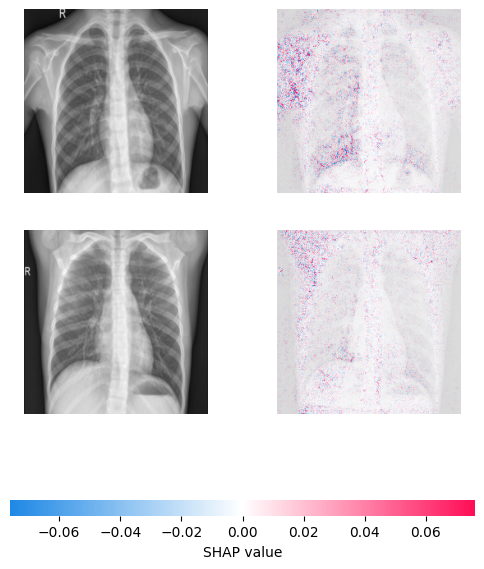

In [ ]:
#SHAP görselleştirme — NORMAL sınıfı
print("SHAP explanation for NORMAL class")
shap.image_plot(shap_values_class0, test_images_np)

SHAP explanation for PNEUMONIA class


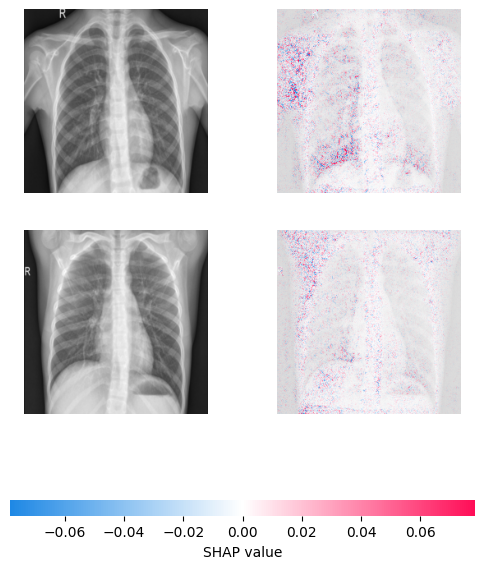

In [ ]:
#SHAP görselleştirme — PNEUMONIA sınıfı
print("SHAP explanation for PNEUMONIA class")
shap.image_plot(shap_values_class1, test_images_np)

In [ ]:
#Tahminleri de yazdır
with torch.no_grad():
    outputs = best_resnet18(test_images)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

for i in range(len(test_images)):
    print(f"Sample {i+1}")
    print("True Label:", test_dataset.classes[test_labels[i].item()])
    print("Predicted Label:", test_dataset.classes[preds[i].item()])
    print("Confidence:", probs[i, preds[i]].item())
    print("-" * 40)

Sample 1
True Label: NORMAL
Predicted Label: NORMAL
Confidence: 0.9255115389823914
----------------------------------------
Sample 2
True Label: NORMAL
Predicted Label: NORMAL
Confidence: 0.9832013249397278
----------------------------------------


Grad-Cam vs SHAP

| Özellik          | Grad-CAM           | SHAP        |
| ---------------- | ------------------ | ----------- |
| Açıklama tipi    | Spatial (bölgesel) | Pixel-level |
| Görsellik        | Net heatmap        | Gürültülü   |
| Medikal uygunluk | ✔ yüksek           | ❌ düşük   |
| Interpretability | Kolay              | Zor         |


Grad-CAM provides more clinically interpretable explanations compared to SHAP for chest X-ray images.

SHAP, Grad-CAM’i desteklemek amacıyla ikinci bir açıklama yöntemi olarak kullanılmıştır. SHAP, piksel bazlı katkı değerleri üretmesine rağmen ortaya çıkan görseller daha dağınık ve lokal olarak daha az anlamlıdır. Buna karşılık Grad-CAM, daha düzenli ve akciğer bölgeleriyle daha iyi örtüşen açıklamalar üretmiştir. Bu durum, bu problem için Grad-CAM’in medikal yorumlama açısından daha uygun olduğunu göstermektedir.

# CRITIC AGENT (Validation of Explanations)

Artık şu soruyu soruyoruz:

Model doğru tahmin yapıyor ama gerçekten doğru yere mi bakıyor?


**Bu aşamada ne yapacağız?**

Trained modeli var (improved CNN).
Şimdi:
* Test setten görüntü alacağız
* Model tahmin yapacak
* Grad-CAM ile heatmap oluşturacağız
* Görüntü üzerine bindireceğiz
* Yorumlayacağız

**IoU mantığı**

IoU şu:
kesişim / birleşim

Yani:

* Modelin baktığı yer (Grad-CAM)
* Gerçek anlamlı bölge (akciğer maskesi)

Ne kadar örtüşüyor?

In [ ]:
#Lung mask
import cv2

def get_lung_mask(image):
    img = np.array(image.resize((224, 224)).convert("L"))

    # normalize
    img = img / 255.0

    # threshold
    _, mask = cv2.threshold((img * 255).astype(np.uint8), 50, 255, cv2.THRESH_BINARY)

    mask = mask / 255.0

    return mask

Amaç: kabaca “akciğer bölgesi”

In [ ]:
#Grad-CAM’i binary yap
def get_cam_mask(cam, threshold=0.4):
    cam_mask = cam.copy()

    cam_mask[cam_mask < threshold] = 0
    cam_mask[cam_mask >= threshold] = 1

    return cam_mask

Heatmap’i 0-1 maskeye çeviriyoruz

Sadece “önemli bölgeleri” bırakıyoruz

In [ ]:
#IoU hesapla
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()

    if union == 0:
        return 0

    return intersection / union

In [ ]:
#Hepsini birleştir
lung_mask = get_lung_mask(image)
cam_mask = get_cam_mask(grayscale_cam)

iou = compute_iou(lung_mask, cam_mask)

print("IoU:", iou)

IoU: 0.6896639806794697


In [ ]:
#Critic Agent kararı
threshold = 0.4

if iou >= threshold:
    print("✅ ACCEPT (Explanation valid)")
else:
    print("❌ REJECT (Explanation not reliable)")

✅ ACCEPT (Explanation valid)


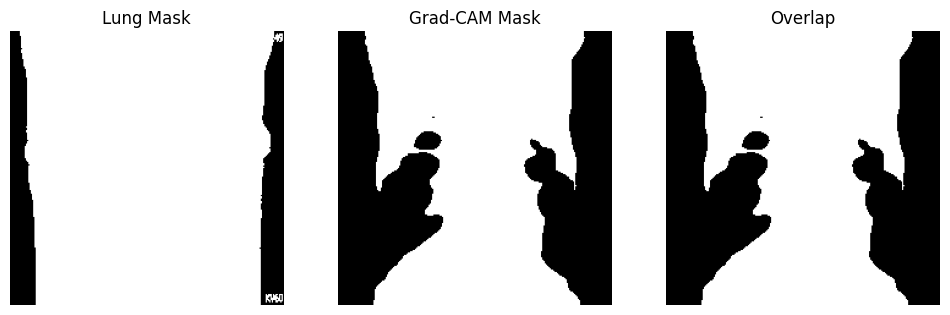

In [ ]:
#Görselleştir
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(lung_mask, cmap="gray")
plt.title("Lung Mask")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cam_mask, cmap="gray")
plt.title("Grad-CAM Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(lung_mask * cam_mask, cmap="gray")
plt.title("Overlap")
plt.axis("off")

plt.show()

**Ne bekliyoruz?**

İyi durumda:
* overlap yüksek
* IoU yüksek
* ACCEPT

Kötü durumda:
* cam kenarlarda
* akciğerle örtüşmez
* REJECT

To evaluate the reliability of explanations, a Critic Agent was introduced to measure the overlap between Grad-CAM heatmaps and lung regions. The Intersection over Union (IoU) metric was used to quantify this alignment. Explanations with IoU above a predefined threshold were accepted as valid, while others were rejected. This allows the system to assess not only prediction accuracy but also explanation correctness.

Sample 1
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Confidence: 0.7573
IoU: 0.5959
Critic Decision: ACCEPT
------------------------------------------------------------


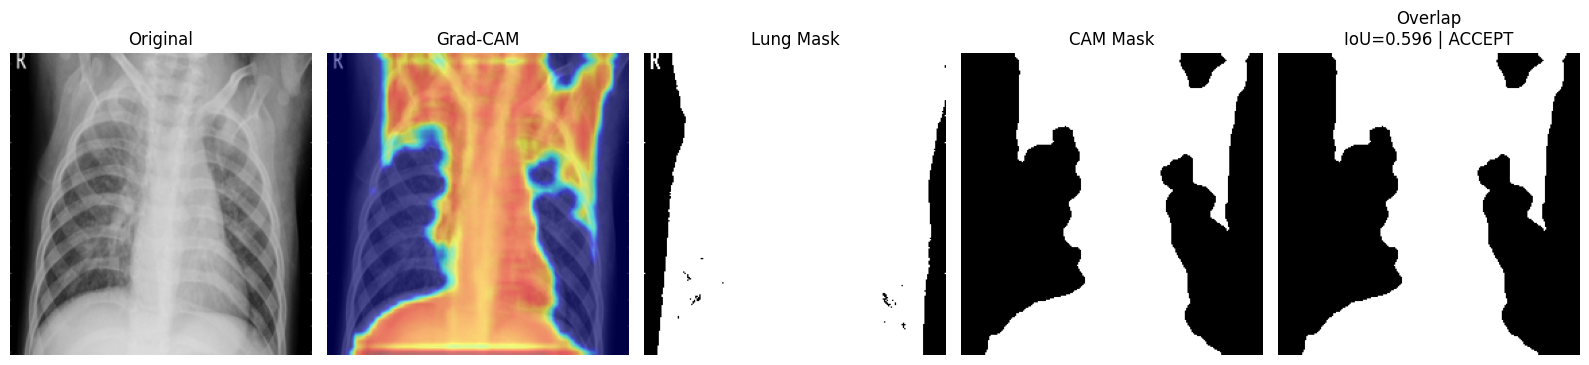

Sample 2
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Confidence: 0.8208
IoU: 0.6628
Critic Decision: ACCEPT
------------------------------------------------------------


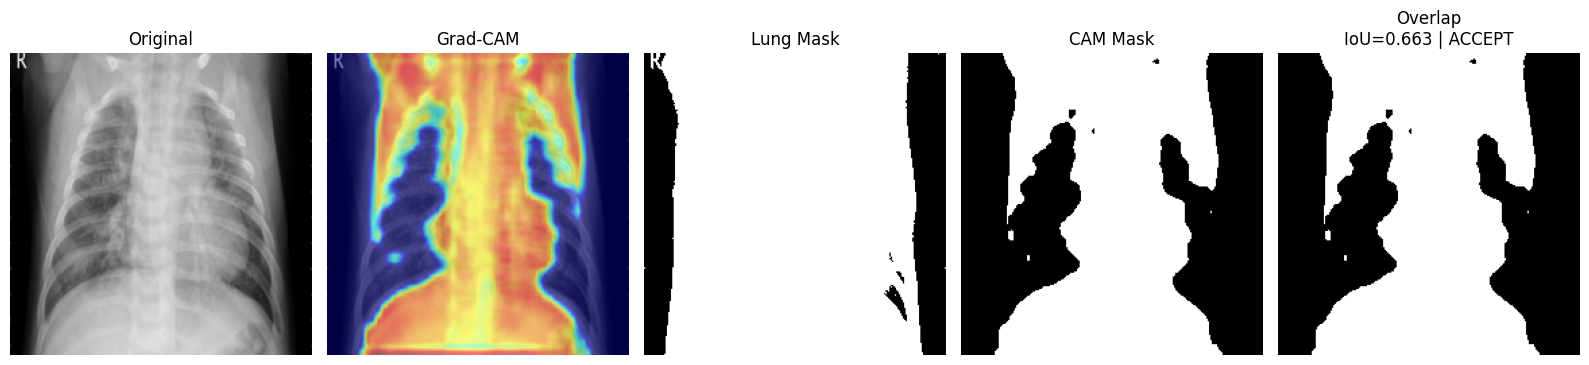

Sample 3
True Label: PNEUMONIA
Predicted Label: NORMAL
Confidence: 0.5240
IoU: 0.0490
Critic Decision: REJECT
------------------------------------------------------------


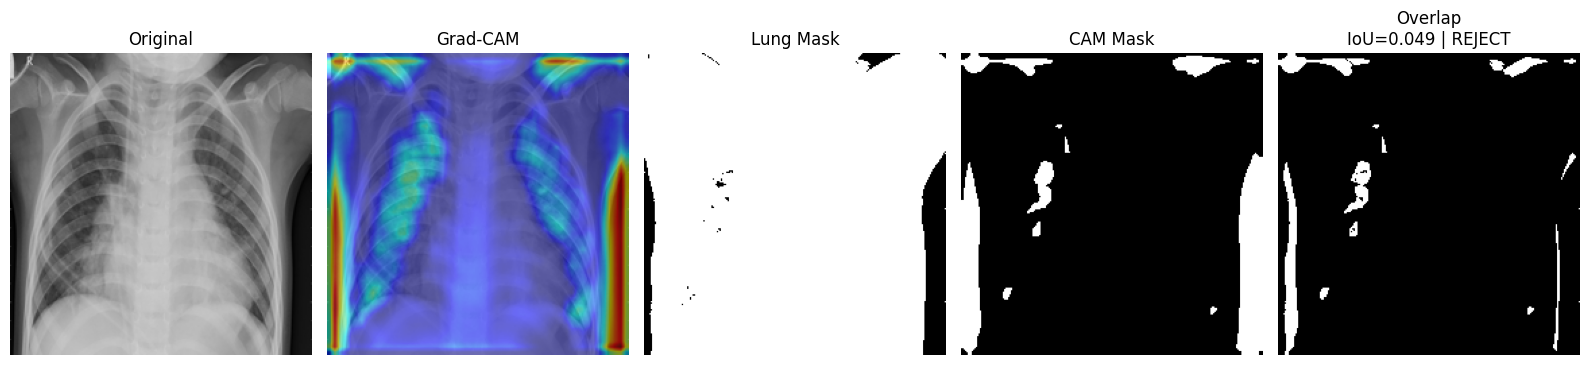

Sample 4
True Label: NORMAL
Predicted Label: NORMAL
Confidence: 0.9204
IoU: 0.0358
Critic Decision: REJECT
------------------------------------------------------------


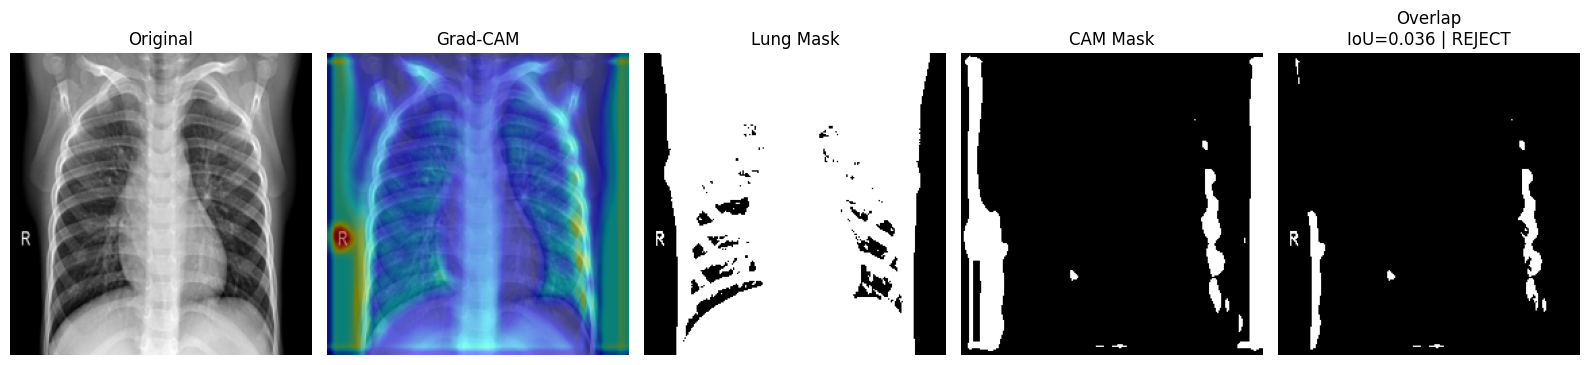

Sample 5
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Confidence: 0.9658
IoU: 0.7692
Critic Decision: ACCEPT
------------------------------------------------------------


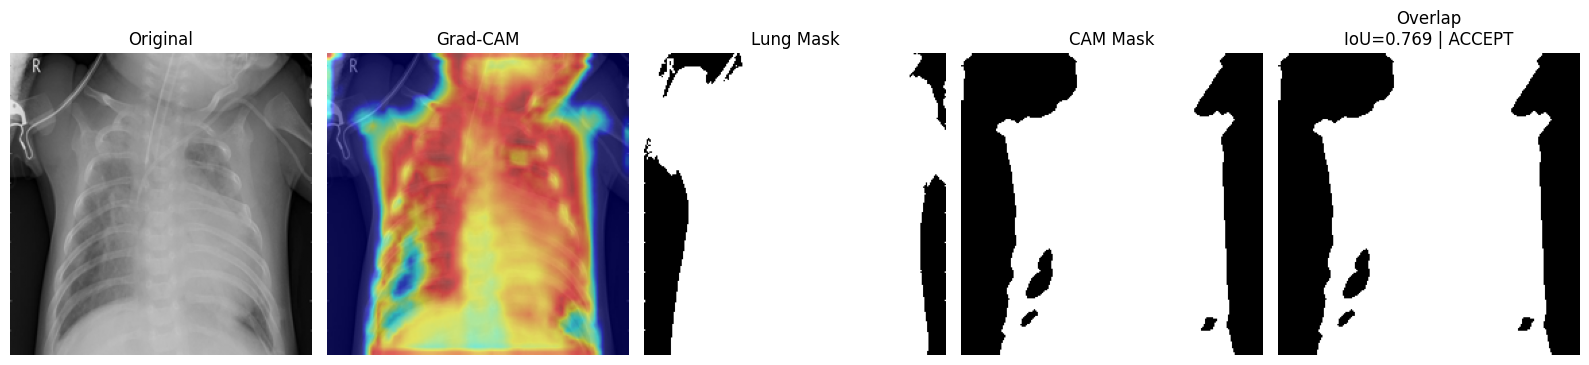

In [ ]:
#test setinden rastgele 5 görüntü seç

def critic_agent_single_image(img_path, true_label, model, target_layer, test_transform, class_names, device, cam_threshold=0.4, iou_threshold=0.4):
    image = Image.open(img_path).convert("RGB")

    input_tensor = test_transform(image).unsqueeze(0).to(device)

    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)
    _, pred = torch.max(output, 1)

    pred_class = pred.item()
    confidence = probs[0, pred_class].item()

    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    image_np = np.array(image.resize((224, 224))) / 255.0
    cam_image = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

    lung_mask = get_lung_mask(image)
    cam_mask = get_cam_mask(grayscale_cam, threshold=cam_threshold)

    iou = compute_iou(lung_mask, cam_mask)

    decision = "ACCEPT" if iou >= iou_threshold else "REJECT"

    return image_np, cam_image, lung_mask, cam_mask, lung_mask * cam_mask, pred_class, confidence, iou, decision


num_samples = 5
selected_samples = random.sample(test_dataset.samples, num_samples)

target_layer = model.features[6]

for idx, (img_path, true_label) in enumerate(selected_samples):
    image_np, cam_image, lung_mask, cam_mask, overlap, pred_class, confidence, iou, decision = critic_agent_single_image(
        img_path=img_path,
        true_label=true_label,
        model=model,
        target_layer=target_layer,
        test_transform=test_transform,
        class_names=test_dataset.classes,
        device=device,
        cam_threshold=0.4,
        iou_threshold=0.4
    )

    print(f"Sample {idx+1}")
    print(f"True Label: {test_dataset.classes[true_label]}")
    print(f"Predicted Label: {test_dataset.classes[pred_class]}")
    print(f"Confidence: {confidence:.4f}")
    print(f"IoU: {iou:.4f}")
    print(f"Critic Decision: {decision}")
    print("-" * 60)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(image_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(cam_image)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(lung_mask, cmap="gray")
    plt.title("Lung Mask")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(cam_mask, cmap="gray")
    plt.title("CAM Mask")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(overlap, cmap="gray")
    plt.title(f"Overlap\nIoU={iou:.3f} | {decision}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Sonuçlar, önerilen Critic Agent’ın güvenilir ve güvenilmez açıklamaları başarılı şekilde ayırt edebildiğini göstermektedir. Yüksek IoU değerine sahip doğru pneumonia tahminleri kabul edilmiş ve modelin anlamlı akciğer bölgelerine odaklandığı görülmüştür.

Buna karşılık yanlış sınıflandırılan örneklerde IoU değerleri oldukça düşük çıkmış ve bu durum Critic Agent tarafından doğru şekilde reddedilmiştir. Bu, hatalı tahminlerin genellikle alakasız bölgelere odaklanma ile ilişkili olduğunu göstermektedir.

Ayrıca bazı doğru tahmin edilen normal görüntülerin de düşük IoU nedeniyle reddedilmesi, modelin doğru sonucu her zaman doğru gerekçeyle üretmediğini göstermektedir. Bu da yalnızca doğruluk metriğine güvenmenin yetersiz olduğunu ortaya koymaktadır.

Pointing Game ekle.
Faithfulness